#### yfinance: comparing performance of major airlines from feb-mar, 2026

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


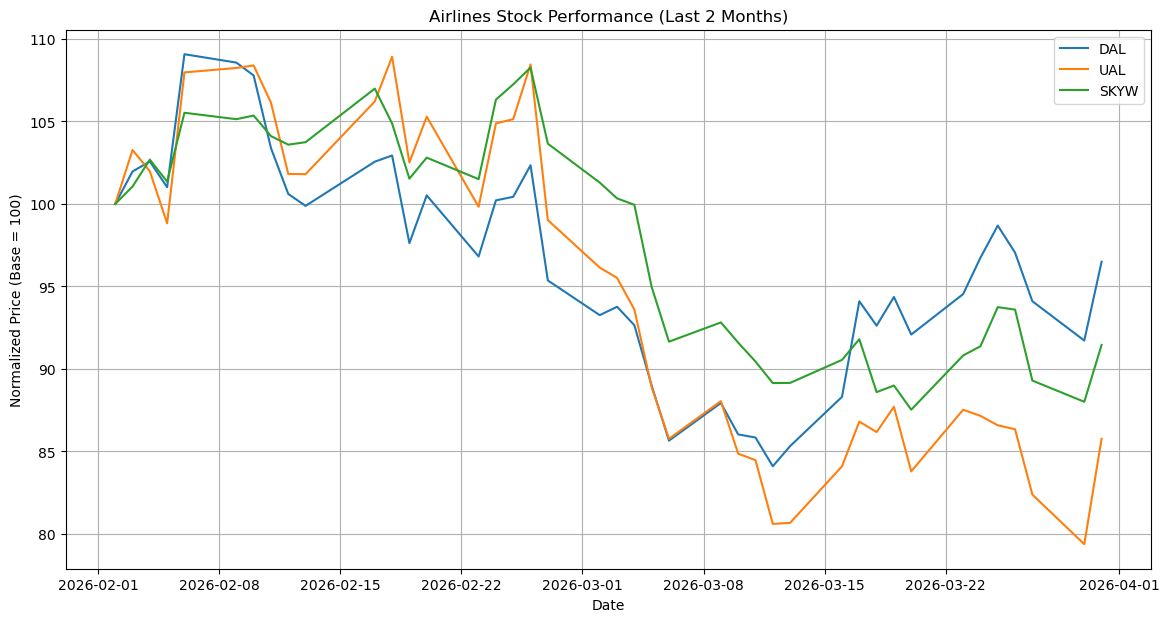

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# --- major airlines ---
tickers = ["DAL", "UAL", "SKYW"]

price_data = []

for ticker in tickers:
    try:
        df = yf.download(ticker, period="2mo")

        if df.empty:
            print(f"{ticker}: No data")
            continue

        # Use Adj Close if available, else Close
        if "Adj Close" in df.columns:
            series = df["Adj Close"]
        else:
            series = df["Close"]

        series.name = ticker
        price_data.append(series)

    except Exception as e:
        print(f"{ticker} failed: {e}")

# --- Combine all series ---
df_prices = pd.concat(price_data, axis=1)

# --- Drop rows where ALL are NaN ---
df_prices = df_prices.dropna(how="all")

# --- Forward fill missing values ---
df_prices = df_prices.ffill()

# --- Ensure we still have data ---
if df_prices.shape[0] == 0:
    raise ValueError("Still no usable data — try removing problematic tickers like 2222.SR")

# --- Normalize ---
normalized = df_prices / df_prices.iloc[0] * 100

# --- Plot ---
plt.figure(figsize=(14, 7))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title("Airlines Stock Performance (Last 2 Months)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100)")
plt.legend()
plt.grid(True)

plt.show()